In [ ]:
!pip install tensorflow matplotlib numpy scikit-learn

Defaulting to user installation because normal site-packages is not writeable


ERROR: Could not find a version that satisfies the requirement tensorflow (from versions: none)
ERROR: No matching distribution found for tensorflow


In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2

from sklearn.metrics import classification_report, confusion_matrix


2026-09-10 00:46:31.513706: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-10 00:46:31.802241: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-10 00:46:32.080418: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1788990392.402977  104359 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1788990392.505976  104359 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-09-10 00:46:32.982903: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU ins

In [2]:
DATA_DIR = "dataset"

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
SEED = 42

training_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

validation_dataset = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

Found 26 files belonging to 3 classes.
Using 21 files for training.
Found 26 files belonging to 3 classes.
Using 5 files for validation.


2026-09-10 00:46:48.615595: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [3]:
class_names = training_dataset.class_names

print("Classes:", class_names)

Classes: ['approved', 'peace', 'wave']


2026-09-10 00:46:56.875129: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


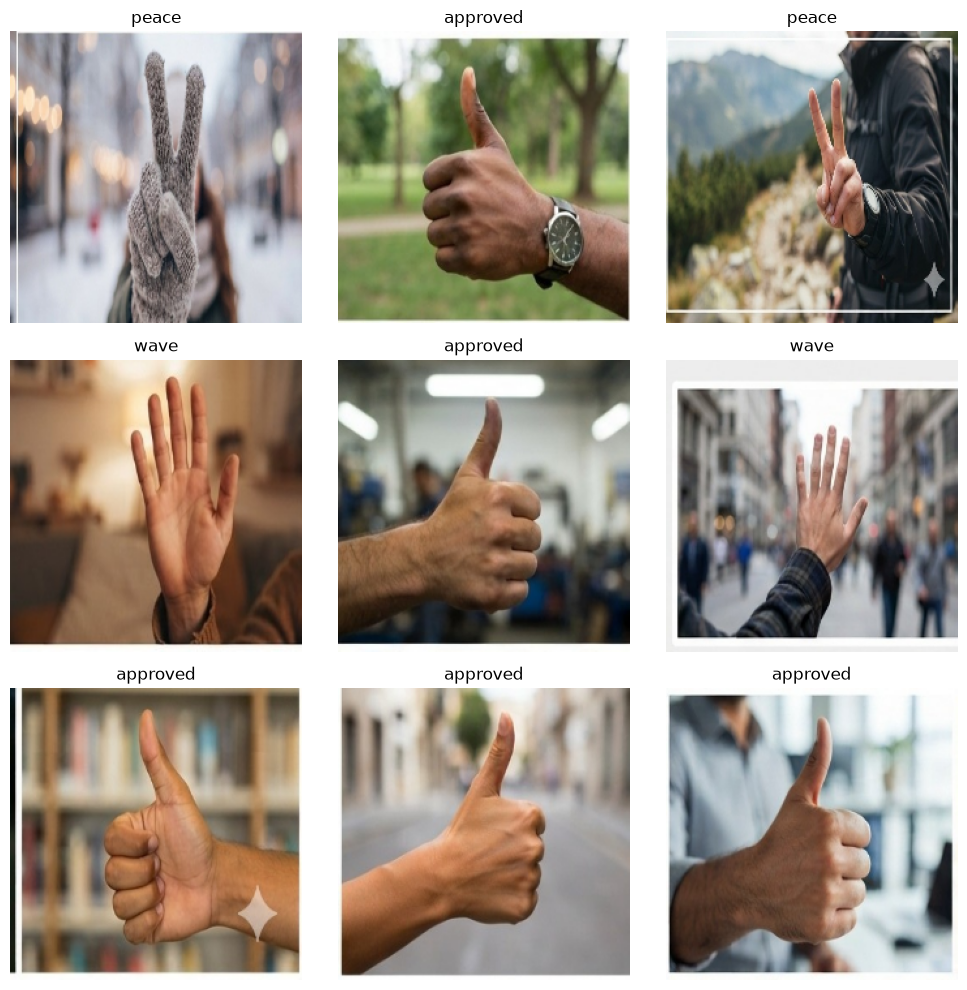

In [4]:
# to see what we're feeding the model ...
plt.figure(figsize=(10, 10))

for images, labels in training_dataset.take(1):
    for i in range(9):
        ax = plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")

plt.tight_layout()
plt.show()

In [5]:
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = training_dataset.prefetch(AUTOTUNE)
validation_dataset = validation_dataset.prefetch(AUTOTUNE)
# .....this just makes loading the images more efficient


In [6]:
# make the model more robust
# it it should not memorize like this exact background + this exact hand position = this class
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
])
# ⚠️ A vertically flipped hand could produce something unrealistic and teach the model unnecessary patterns

In [7]:
# the interesting part: using a model that has alreay learned useful features from a huge dataset (ImageNet) and applying it to this smaller dataset
base_model = MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [9]:
# MobileNetV2 wasn't trained to recognize our classes, so we need to add a new classification layer for our specific task
inputs = keras.Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = tf.keras.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)

outputs = layers.Dense(
    len(class_names),
    activation="softmax"
)(x)

model = keras.Model(inputs, outputs)

In [10]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential (Sequential)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract_1 (Subtract)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [11]:
# compiling the model
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)


In [12]:
# training the model
EPOCHS = 10

history = model.fit(
    train_dataset,
    validation_data=validation_dataset,
    epochs=EPOCHS
)

Epoch 1/10


/home/devtole/Desktop/csk-vision/venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
2026-09-10 00:47:41.909093: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 101154816 exceeds 10% of free system memory.
2026-09-10 00:47:42.060719: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102969216 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 14s 14s/step - accuracy: 0.5238 - loss: 1.3923 - val_accuracy: 0.6000 - val_loss: 1.0405
Epoch 2/10


2026-09-10 00:47:46.336394: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 101154816 exceeds 10% of free system memory.
2026-09-10 00:47:46.486660: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 102969216 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.2381 - loss: 1.4627 - val_accuracy: 0.6000 - val_loss: 1.0351
Epoch 3/10


2026-09-10 00:47:48.334747: W external/local_xla/xla/tsl/framework/cpu_allocator_impl.cc:83] Allocation of 101154816 exceeds 10% of free system memory.


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5238 - loss: 1.1290 - val_accuracy: 0.6000 - val_loss: 1.0296
Epoch 4/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3810 - loss: 1.2992 - val_accuracy: 0.6000 - val_loss: 1.0241
Epoch 5/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.4762 - loss: 1.2063 - val_accuracy: 0.6000 - val_loss: 1.0195
Epoch 6/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3333 - loss: 1.3439 - val_accuracy: 0.6000 - val_loss: 1.0158
Epoch 7/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.3333 - loss: 1.1751 - val_accuracy: 0.6000 - val_loss: 1.0128
Epoch 8/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.2381 - loss: 1.2811 - val_accuracy: 0.6000 - val_loss: 1.0101
Epoch 9/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.5714 - loss: 1.0509 - val_accuracy: 0.6000 - val_loss: 1.0081
Epoch 10/10
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.3810 - loss: 1.0180 - val_accuracy: 0.6000 - val_loss: 1.0062


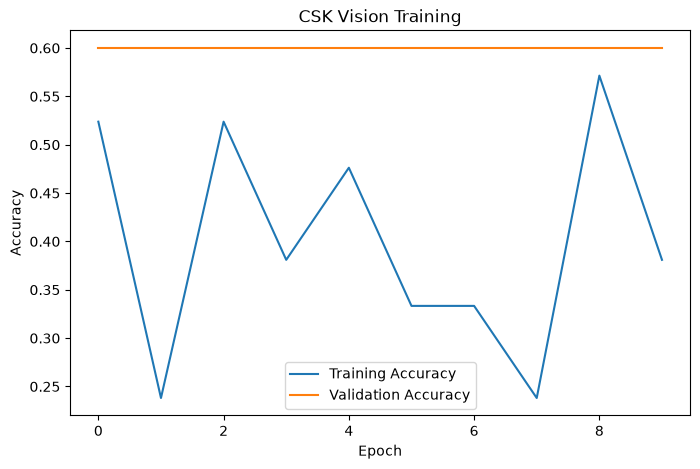

In [13]:
# visualizing 
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("CSK Vision Training")
plt.legend()

plt.show()

In [14]:
# evaluate the model
loss, accuracy = model.evaluate(validation_dataset)

print(f"Validation accuracy: {accuracy:.2%}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 315ms/step - accuracy: 0.6000 - loss: 1.0062
Validation accuracy: 60.00%


In [15]:
# confusion matrix
y_true = []
y_pred = []

for images, labels in validation_dataset:
    predictions = model.predict(images, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(predictions, axis=1))



2026-09-10 00:48:25.865838: I tensorflow/core/framework/local_rendezvous.cc:405] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


In [16]:
cm = confusion_matrix(y_true, y_pred)

print(cm)


[[3 0 0]
 [1 0 0]
 [0 1 0]]


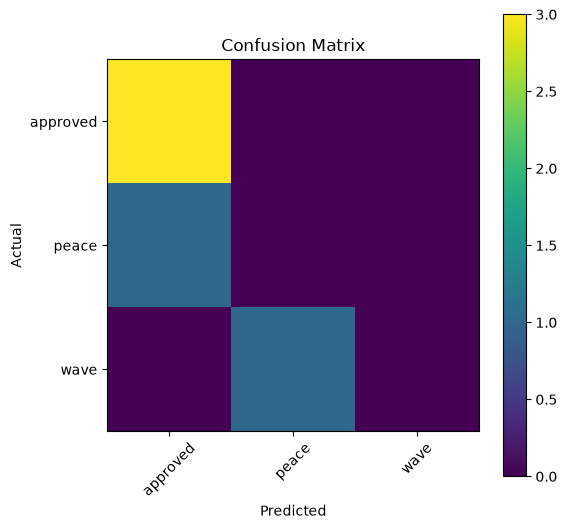

In [17]:
# nicer visualiztion
plt.figure(figsize=(6, 6))

plt.imshow(cm)

plt.xticks(
    range(len(class_names)),
    class_names,
    rotation=45
)

plt.yticks(
    range(len(class_names)),
    class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.colorbar()

plt.show()

In [18]:
# classification report
print(
    classification_report(
        y_true,
        y_pred,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

    approved       0.75      1.00      0.86         3
       peace       0.00      0.00      0.00         1
        wave       0.00      0.00      0.00         1

    accuracy                           0.60         5
   macro avg       0.25      0.33      0.29         5
weighted avg       0.45      0.60      0.51         5



/home/devtole/Desktop/csk-vision/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/devtole/Desktop/csk-vision/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/devtole/Desktop/csk-vision/venv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"

In [19]:
# saving the model
model.save("csk_vision_model.keras")